In [1]:
import torch

from torch.distributions import Normal

import matplotlib.pyplot as plt

torch.set_default_device('cuda:0')

In [2]:
prior = Normal(0.0, 5.0)

num_samples = 10000
z = prior.sample([num_samples])

n = 100
x = Normal(z, 1.0).sample([100]).permute(1,0)

In [3]:
class Encoder(torch.nn.Module):
    def __init__(self, num_hidden=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n, num_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(num_hidden, num_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(num_hidden, 2)  # output mean and log stddev
        )

    def forward(self, x):
        params = self.net(x)
        mean = params[:, 0]
        log_std = params[:, 1].clamp(-8.0, 8.0)
        return mean, log_std

In [4]:
encoder = Encoder(num_hidden=32)

In [5]:
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-4)

In [6]:
num_epochs = 10000
batch_size = 128

for epoch in range(num_epochs):
    idx = torch.randint(0, num_samples, (batch_size,))
    x_batch = x[idx]
    z_batch = z[idx]

    mean, log_std = encoder(x_batch)
    std = torch.exp(log_std)

    # Gaussian variational posterior q(z|x)
    loss = - Normal(mean, std).log_prob(z_batch).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 5.3143
Epoch 100, Loss: 2.2426
Epoch 200, Loss: 1.5172
Epoch 300, Loss: 1.3596
Epoch 400, Loss: 1.4769
Epoch 500, Loss: 0.9496
Epoch 600, Loss: 0.4979
Epoch 700, Loss: 0.3688
Epoch 800, Loss: 0.4284
Epoch 900, Loss: 0.1835
Epoch 1000, Loss: 0.3112
Epoch 1100, Loss: 0.1377
Epoch 1200, Loss: 0.1539
Epoch 1300, Loss: 0.0683
Epoch 1400, Loss: 0.2544
Epoch 1500, Loss: 0.1315
Epoch 1600, Loss: 0.1503
Epoch 1700, Loss: 0.0444
Epoch 1800, Loss: 0.0209
Epoch 1900, Loss: -0.0144
Epoch 2000, Loss: 0.0531
Epoch 2100, Loss: 0.0684
Epoch 2200, Loss: -0.1534
Epoch 2300, Loss: -0.0526
Epoch 2400, Loss: -0.2381
Epoch 2500, Loss: -0.1647
Epoch 2600, Loss: -0.2198
Epoch 2700, Loss: -0.1100
Epoch 2800, Loss: -0.3450
Epoch 2900, Loss: -0.3650
Epoch 3000, Loss: -0.3030
Epoch 3100, Loss: -0.3773
Epoch 3200, Loss: -0.3861
Epoch 3300, Loss: -0.5229
Epoch 3400, Loss: -0.4576
Epoch 3500, Loss: -0.5799
Epoch 3600, Loss: -0.4128
Epoch 3700, Loss: -0.4579
Epoch 3800, Loss: -0.6582
Epoch 3900, Loss: -

We evaluate on samples from the true generative model:

In [7]:
z_test = prior.sample([num_samples])

x_test = Normal(z_test, 1.0).sample([n]).permute(1,0)

In [8]:
m, ls = encoder(x_test)

In [9]:
confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

In [10]:
lower = (m.unsqueeze(-1) - quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()
upper = (m.unsqueeze(-1) + quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()

In [11]:
coverage_probs = ((z_test.cpu().unsqueeze(-1) >= lower) * (z_test.cpu().unsqueeze(-1) <= upper)).float().mean(0)

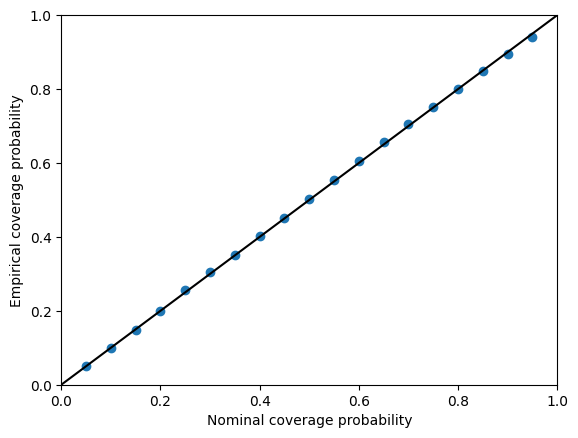

In [12]:
_ = plt.scatter(confidence_levels.cpu(), coverage_probs.cpu())
_ = plt.axline((0,0), slope = 1, color = 'black')
_ = plt.xlim(0, 1)
_ = plt.ylim(0, 1)
_ = plt.xlabel('Nominal coverage probability')
_ = plt.ylabel('Empirical coverage probability')

Now we evaluate on samples from an incorrect generative model — the conditional distribution of $x$ has twice the variance of the true $p(x | z)$:

In [13]:
z_test = prior.sample([num_samples])

x_test = Normal(z_test, 2.0).sample([n]).permute(1,0)

In [14]:
m, ls = encoder(x_test)

In [15]:
confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

In [16]:
lower = (m.unsqueeze(-1) - quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()
upper = (m.unsqueeze(-1) + quantiles * torch.exp(ls.unsqueeze(-1))).detach().cpu()

In [17]:
coverage_probs = ((z_test.cpu().unsqueeze(-1) >= lower) * (z_test.cpu().unsqueeze(-1) <= upper)).float().mean(0)

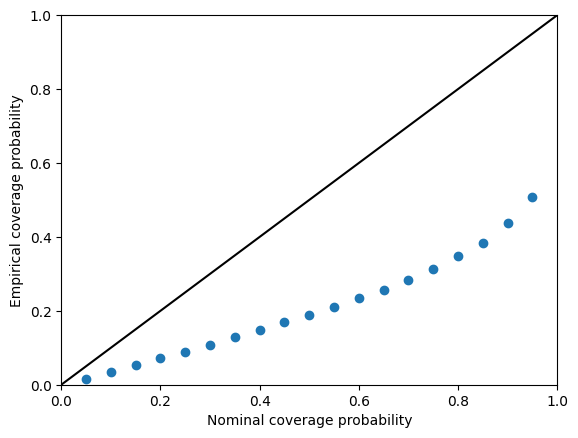

In [18]:
_ = plt.scatter(confidence_levels.cpu(), coverage_probs.cpu())
_ = plt.axline((0,0), slope = 1, color = 'black')
_ = plt.xlim(0, 1)
_ = plt.ylim(0, 1)
_ = plt.xlabel('Nominal coverage probability')
_ = plt.ylabel('Empirical coverage probability')